A Jupyter Notebook to grab quick and easy plots of the predictions based on the prostate MRI segmentation models.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

import torch
from torch.utils.data import DataLoader

from prostatemri_dataset import load_images, MRIDataset
from mriseg_models import SimpleUNet, TLDeepLabV3MobileNet

In [2]:
# Load validation dataset and create dataloader for plotting

val_images = load_images("val")

# Wrap the datasets and create dataloaders
val_dataset = MRIDataset(val_images)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [6]:
# Load the trained model

model = SimpleUNet()
model.load_state_dict(torch.load("prostate_unet.pth"))

# model = TLDeepLabV3MobileNet(backbone_unfreeze_substrings = ("5", "6"), classifier_unfreeze_last_K = 4)
# model.load_state_dict(torch.load("prostate_transfer_model.pth"))

<All keys matched successfully>

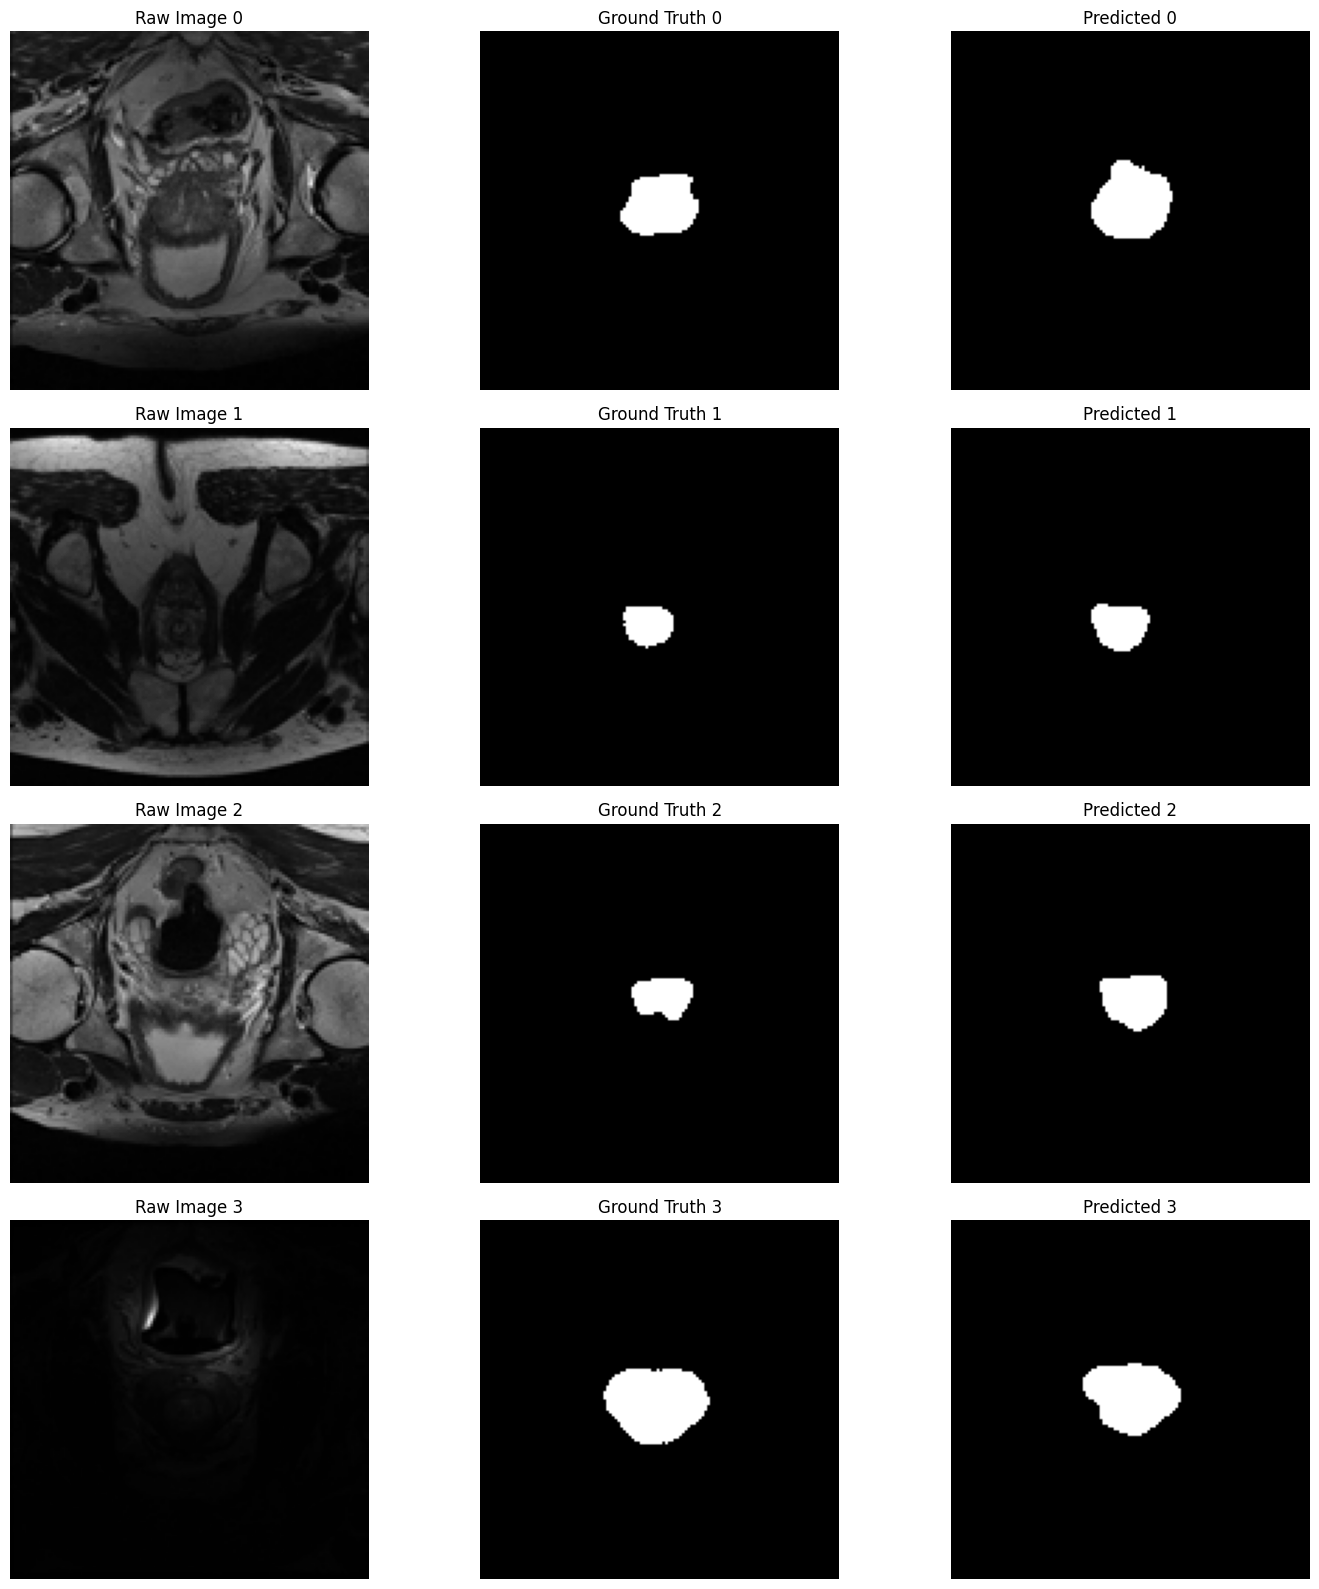

In [7]:
# Visualize predictions on validation set
num_samples = 4

fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))

model.eval()
with torch.no_grad():
    for idx in range(num_samples):
        images, _ = val_dataset[idx]
        
        # Add batch dimension and get prediction
        image_batch = images.unsqueeze(0)
        outputs = model(image_batch)
        
        # The transfer learning-based model outputs a dict, access the 'out' key for the logits
        if isinstance(outputs, dict) and 'out' in outputs:
            outputs = outputs['out']

        # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
        predicted_mask = torch.sigmoid(outputs).squeeze(0).squeeze(0).numpy()
        predicted_mask = (predicted_mask > 0.5).astype(np.uint8)
        
        # Grab raw PIL image from the dataset (the "image" drawn directly from the dataset is normalized)
        raw_pil, mask = val_dataset.base_dataset[idx]     # PIL.Image
        raw_np = np.array(raw_pil.convert("L"))        # (H, W) uint8
        mask_np = np.array(mask)

        # Display
        axes[idx, 0].imshow(raw_np, cmap='gray', vmin=0, vmax=255)
        axes[idx, 0].set_title(f'Raw Image {idx}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(mask_np, cmap='gray')
        axes[idx, 1].set_title(f'Ground Truth {idx}')
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(predicted_mask, cmap='gray')
        axes[idx, 2].set_title(f'Predicted {idx}')
        axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()